### Tutorial 5 - Statistical Analysis

Packages to install: 
* `scipy`
* `statsmodels`

### Question 1

#### Descriptive Statistics

1. Load the data below into a Pandas DataFrame.
3. Compute the mean, median, and standard deviation of the "exam_score" column.
4. Create a scatter plot to examine the relationship between "study_hours" and "exam_score".Add appropriate labels and a title to the plot.
5. Compute the correlation coefficient between "study_hours" and "exam_score". Interpret the strength and direction of the correlation.
6. Perform a one-sample t-test (**ttest_1samp**) to determine if the mean "exam_score" is significantly different from 75.
Use a significance level of 0.05.

```
data = {
'student_id':[1,2,3,4,5,6,7,8,9,10],
'exam_score':[85,92,78,88,95,83,90,88,75,92],
'study_hours':[6,8,4,7,9,5,7,6,3,8],
'subject':['Math','Science','English','Math','Science','English','Math','Science','English','Math']
}
```

In [1]:
import pandas as pd

data = {
'student_id':[1,2,3,4,5,6,7,8,9,10],
'exam_score':[85,92,78,88,95,83,90,88,75,92],
'study_hours':[6,8,4,7,9,5,7,6,3,8],
'subject':['Math','Science','English','Math','Science','English','Math','Science','English','Math']
}

df = pd.DataFrame(data)

In [2]:
df

,student_id,exam_score,study_hours,subject
0,1,85,6,Math
1,2,92,8,Science
2,3,78,4,English
3,4,88,7,Math
4,5,95,9,Science
5,6,83,5,English
6,7,90,7,Math
7,8,88,6,Science
8,9,75,3,English
9,10,92,8,Math


In [7]:
df.describe()

,student_id,exam_score,study_hours
count,10.00000,10.000000,10.000000
mean,5.50000,86.600000,6.300000
std,3.02765,6.397916,1.888562
min,1.00000,75.000000,3.000000
25%,3.25000,83.500000,5.250000
50%,5.50000,88.000000,6.500000
75%,7.75000,91.500000,7.750000
max,10.00000,95.000000,9.000000


In [9]:
import numpy as np

np.median(df['exam_score'])

88.0

In [10]:
np.mean(df['exam_score'])

86.6

In [11]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'My tittle')

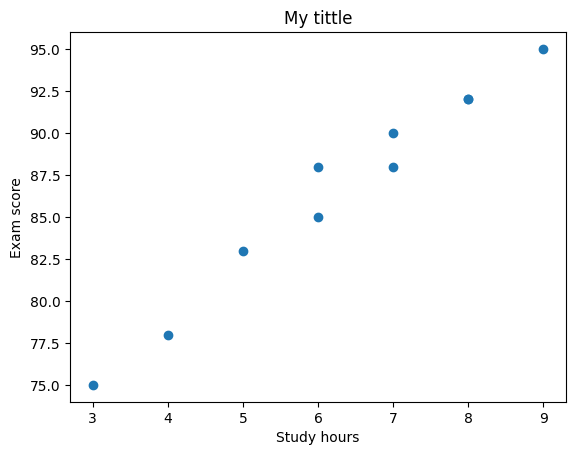

In [15]:
plt.scatter(df['study_hours'], df['exam_score'])
plt.xlabel('Study hours')
plt.ylabel('Exam score')
plt.title('My tittle')

In [17]:
df['study_hours'].corr(df['exam_score'])

0.9857855739960909

In [18]:
import scipy as sc

In [19]:
sc.stats.ttest_1samp(df['exam_score'], 75) 

TtestResult(statistic=5.733494934974746, pvalue=0.00028210637545618444, df=9)

In [20]:
0.00028210637545618444 < 0.05

True

In [ ]:
Alt hypo = the mean "exam_score" is significantly different from 75 <----- ACCEPT ALT HYPO
Null  = the mean "exam_score" is close to  75  <----- REJECT NULL HYPO

### Question 2

#### Two sample t-test

1. Load the data into a dataframe, which contains information about a marketing campaign.
2. Perform a two-sample t-test to determine if there is a significant difference in the average amount spent by customers between two different marketing channels ("Channel_A" and "Channel_B").
3. Create a bar plot to visualize the average amount spent by customers for each channel.
Interpret the results of the t-test and the bar plot.

Data:  
```
data = {
'Customer_ID':[1,2,3,4,5,6,7,8,9,10],
'Amount_Spent':[50.25,75.5,60.75,80,55.25,90.5,65,70.75,85.25,95],
'Marketing_Channel':['Channel_A','Channel_B','Channel_A','Channel_B','Channel_A','Channel_B','Channel_A','Channel_B','Channel_A','Channel_B']
}
```

In [21]:
data = {
'Customer_ID':[1,2,3,4,5,6,7,8,9,10],
'Amount_Spent':[50.25,75.5,60.75,80,55.25,90.5,65,70.75,85.25,95],
'Marketing_Channel':['Channel_A','Channel_B','Channel_A','Channel_B','Channel_A','Channel_B','Channel_A','Channel_B','Channel_A','Channel_B']
}

df = pd.DataFrame(data)

In [22]:
df

,Customer_ID,Amount_Spent,Marketing_Channel
0,1,50.25,Channel_A
1,2,75.50,Channel_B
2,3,60.75,Channel_A
3,4,80.00,Channel_B
4,5,55.25,Channel_A
5,6,90.50,Channel_B
6,7,65.00,Channel_A
7,8,70.75,Channel_B
8,9,85.25,Channel_A
9,10,95.00,Channel_B


if there is a significant difference in the average amount spent by customers between two different marketing channels 

In [ ]:
NULL  = There is NO significant difference betweent the avg amount spent by cust between A and B channel
ALT = There is significant difference between the avg amount spent by cust between A and B channel

In [24]:
channel_a = df[df['Marketing_Channel']=='Channel_A']
channel_b = df[df['Marketing_Channel']=='Channel_B']

In [26]:
channel_b

,Customer_ID,Amount_Spent,Marketing_Channel
1,2,75.50,Channel_B
3,4,80.00,Channel_B
5,6,90.50,Channel_B
7,8,70.75,Channel_B
9,10,95.00,Channel_B


In [27]:
sc.stats.ttest_ind(channel_a['Amount_Spent'], channel_b['Amount_Spent'])

TtestResult(statistic=-2.523510856132338, pvalue=0.03561351047673243, df=8.0)

In [28]:
    0.035613510476732 < 0.05

True

In [ ]:
NULL  = There is NO significant difference betweent the avg amount spent by cust between A and B channel
ALT = 

In [ ]:
we REJECT THE NULL HYPO.
we ACCEPT alt hypo.

There is significant difference between the avg amount spent by cust between A and B channel

<BarContainer object of 2 artists>

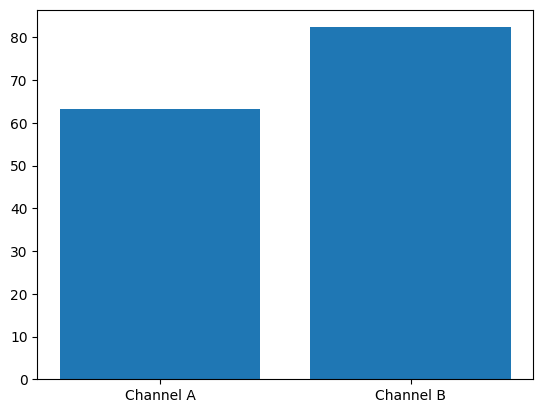

In [29]:
plt.bar(["Channel A","Channel B"],
        [channel_a['Amount_Spent'].mean(), channel_b['Amount_Spent'].mean()])

### Question 3

1. Fit a simple linear regression model to predict "exam_score" based on "study_hours". Use OLS package by `statsmodels` to fit an OLS model.  
   Before fitting, please add the y-intercept using the `sm.add_constant()` function.  
4. Interpret the coefficients and assess the model's goodness of fit.
5. Do a scatter plot for both variables
6. Visualize the regression line on a scatter plot.

```
data = {
'student_id':[1,2,3,4,5,6,7,8,9,10],
'exam_score':[85,92,78,88,95,83,90,88,75,92],
'study_hours':[6,8,4,7,9,5,7,6,3,8],
'subject':['Math','Science','English','Math','Science','English','Math','Science','English','Math']
}
```

In [30]:
data = {
'student_id':[1,2,3,4,5,6,7,8,9,10],
'exam_score':[85,92,78,88,95,83,90,88,75,92],
'study_hours':[6,8,4,7,9,5,7,6,3,8],
'subject':['Math','Science','English','Math','Science','English','Math','Science','English','Math']
}

df = pd.DataFrame(data)

In [32]:
df

,student_id,exam_score,study_hours,subject
0,1,85,6,Math
1,2,92,8,Science
2,3,78,4,English
3,4,88,7,Math
4,5,95,9,Science
5,6,83,5,English
6,7,90,7,Math
7,8,88,6,Science
8,9,75,3,English
9,10,92,8,Math


In [34]:
from statsmodels.regression.linear_model import OLS

In [33]:
X = df['study_hours']
y = df['exam_score']

In [39]:
X

0    6
1    8
2    4
3    7
4    9
5    5
6    7
7    6
8    3
9    8
Name: study_hours, dtype: int64

In [40]:
import statsmodels.api as sm

X =sm.add_constant(X)

In [41]:
X

,const,study_hours
0,1.0,6
1,1.0,8
2,1.0,4
3,1.0,7
4,1.0,9
5,1.0,5
6,1.0,7
7,1.0,6
8,1.0,3
9,1.0,8


In [42]:
model = OLS(y,X).fit()

In [43]:
model.summary()

/Volumes/Data/miniconda3/envs/wif3009/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  k, _ = kurtosistest(a, axis)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             exam_score   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     275.4
Date:                Fri, 05 Apr 2024   Prob (F-statistic):           1.76e-07
Time:                        15:46:57   Log-Likelihood:                -14.385
No. Observations:                  10   AIC:                             32.77
Df Residuals:                       8   BIC:                             33.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          65.5607      1.318     49.742      0.000      62.521      68.600
study_hours     3.3396      0.201     16.596      0.000       2.876       3.804
==============================================================================
Omnibus:                        6.042   Durbin-Watson:                   1.283
Prob(Omnibus):                  0.049   Jarque-Bera (JB):                2.639
Skew:                           1.243   Prob(JB):                        0.267
Kurtosis:                       3.398   Cond. No.                         24.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 1.0, 'My tittle')

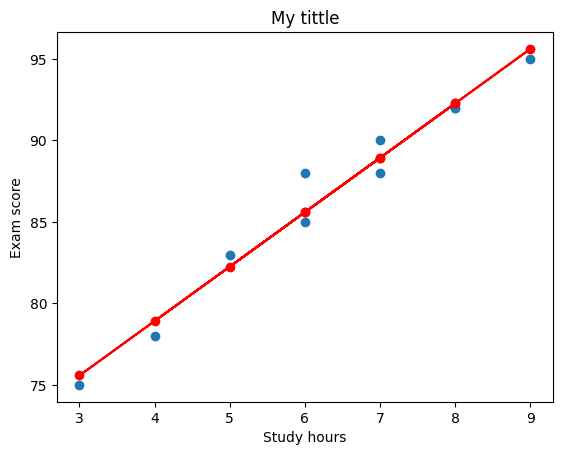

In [48]:
plt.scatter(df['study_hours'], df['exam_score'])
plt.plot(df['study_hours'], model.predict(X), color = 'red', marker='o')
plt.xlabel('Study hours')
plt.ylabel('Exam score')
plt.title('My tittle')

### Question 4

#### Analysis of Variance (ANOVA)

1. Import the data into a dataframe
2. Groupby the data based on subject
3. Conduct a one-way ANOVA to compare the mean "exam_score" across different "subject" categories.  
4. Determine if there are significant differences in exam scores among the subjects.  
5. Use boxplot to visualize the exam scores by subject

Use the data below:  

```
data = {
'student_id':[1,2,3,4,5,6,7,8,9,10],
'exam_score':[85,92,78,88,95,83,90,88,75,92],
'study_hours':[6,8,4,7,9,5,7,6,3,8],
'subject':['Math','Science','English','Math','Science','English','Math','Science','English','Math']
}
```


In [49]:
data = {
'student_id':[1,2,3,4,5,6,7,8,9,10],
'exam_score':[85,92,78,88,95,83,90,88,75,92],
'study_hours':[6,8,4,7,9,5,7,6,3,8],
'subject':['Math','Science','English','Math','Science','English','Math','Science','English','Math']
}

df = pd.DataFrame(data)

In [50]:
df

,student_id,exam_score,study_hours,subject
0,1,85,6,Math
1,2,92,8,Science
2,3,78,4,English
3,4,88,7,Math
4,5,95,9,Science
5,6,83,5,English
6,7,90,7,Math
7,8,88,6,Science
8,9,75,3,English
9,10,92,8,Math


In [52]:
splitted = [doc for doc in df.groupby('subject')]

In [53]:
splitted

[('English',
     student_id  exam_score  study_hours  subject
  2           3          78            4  English
  5           6          83            5  English
  8           9          75            3  English),
 ('Math',
     student_id  exam_score  study_hours subject
  0           1          85            6    Math
  3           4          88            7    Math
  6           7          90            7    Math
  9          10          92            8    Math),
 ('Science',
     student_id  exam_score  study_hours  subject
  1           2          92            8  Science
  4           5          95            9  Science
  7           8          88            6  Science)]

In [57]:
eng = splitted[0][1]
math = splitted[1][1]
science = splitted[2][1]

In [59]:
math

,student_id,exam_score,study_hours,subject
0,1,85,6,Math
3,4,88,7,Math
6,7,90,7,Math
9,10,92,8,Math


In [ ]:
if there are significant differences in exam scores among the subjects

In [ ]:
NULL = no significant differenct  <---- REJECT
ALT = there is a significant diff <---- ACCEPT

In [60]:
sc.stats.f_oneway(eng['exam_score'],
                  math['exam_score'],
                  science['exam_score'])

F_onewayResult(statistic=11.834786917740331, pvalue=0.005680231623164286)

In [61]:
0.005680231623164 < 0.05

True

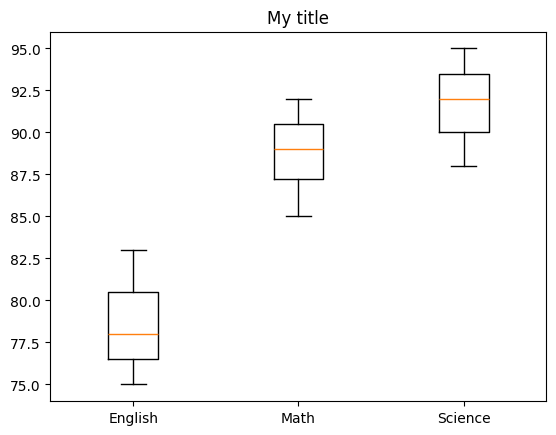

In [64]:
plt.boxplot([eng['exam_score'],
                  math['exam_score'],
                  science['exam_score']],
           labels=['English','Math','Science'])
plt.title('My title')
plt.show()